Đang tải dữ liệu và nạp mô hình...
✅ Đã nạp thành công trọng số từ: runs/mnist_simplecnn_hyper/checkpoints/best\ckpt-20


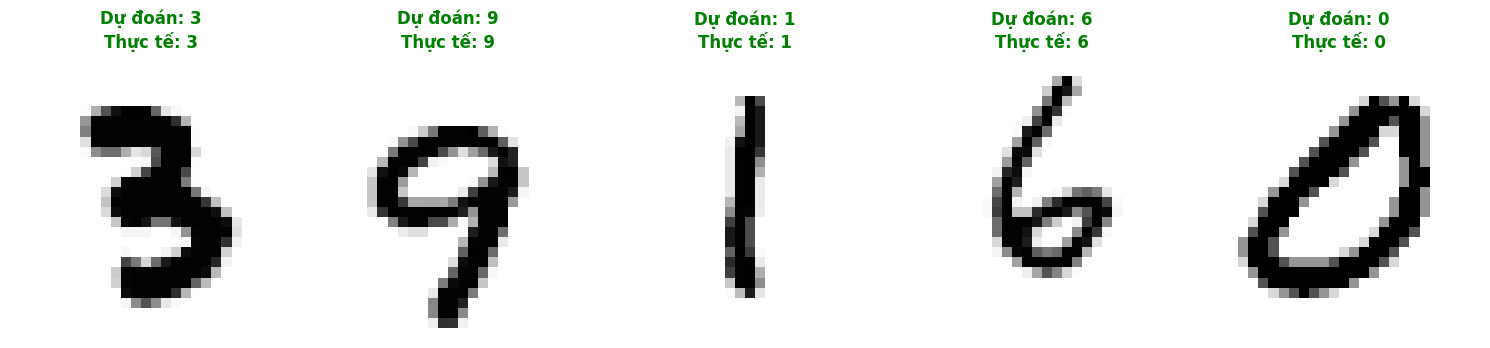

In [49]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Import các module từ project của bạn
from datasets import Mnist
from model.simple_cnn import SimpleCNN

def main():
    print("Đang tải dữ liệu và nạp mô hình...")
    
    # 1. Tải dữ liệu test MNIST
    dataset = Mnist()
    x_test = dataset.x_test
    y_test = dataset.y_test

    # 2. Khởi tạo lại mô hình (Phải giống hệt với lúc bạn cấu hình train)
    # Nếu lúc train bạn dùng --hyper-mode, hãy đổi hyper_mode=True ở đây
    model = SimpleCNN(num_classes=10, hyper_mode=True)

    # Chạy thử 1 batch rỗng để mô hình tự khởi tạo kích thước các lớp (build model)
    dummy_input = tf.zeros((1, 28, 28, 1), dtype=tf.float32)
    model(dummy_input, training=False)

    # 3. Nạp trọng số đã train (Checkpoint)
    # Lưu ý: Cập nhật lại đường dẫn này cho khớp với thư mục lưu của bạn.
    # Dựa vào log của bạn ở trên, đường dẫn có vẻ là: 'runs/mnist_simplecnn/checkpoints/latest'
    # Nếu chạy mặc định thì nó là 'checkpoints/latest' hoặc 'checkpoints/best'
    checkpoint_dir = 'runs/mnist_simplecnn_hyper/checkpoints/best' 
    
    checkpoint = tf.train.Checkpoint(model=model)
    manager = tf.train.CheckpointManager(checkpoint, directory=checkpoint_dir, max_to_keep=1)
    
    if manager.latest_checkpoint:
        checkpoint.restore(manager.latest_checkpoint).expect_partial()
        print(f"✅ Đã nạp thành công trọng số từ: {manager.latest_checkpoint}")
    else:
        print("❌ Không tìm thấy checkpoint! Hãy kiểm tra lại đường dẫn biến checkpoint_dir.")
        return

    # 4. Chọn ngẫu nhiên 5 bức ảnh để kiểm tra
    num_samples = 5
    indices = random.sample(range(len(x_test)), num_samples)

    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices):
        image = x_test[idx]
        true_label = np.argmax(y_test[idx]) # Chuyển nhãn (one-hot) về số nguyên

        # 5. Dự đoán
        # Thêm chiều batch ở đầu (28, 28, 1) -> (1, 28, 28, 1) để đưa vào mạng
        image_batch = np.expand_dims(image, axis=0) 
        logits = model(image_batch, training=False)
        predicted_label = np.argmax(tf.nn.softmax(logits).numpy()) # Lấy class có xác suất cao nhất

        # 6. Hiển thị ảnh kèm theo nhãn
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(np.reshape(image, (28, 28)), cmap='Greys', interpolation='nearest')
        
        # Đổi màu text: Xanh nếu đoán ĐÚNG, Đỏ nếu đoán SAI
        color = 'green' if predicted_label == true_label else 'red'
        plt.title(f"Dự đoán: {predicted_label}\nThực tế: {true_label}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()

In [50]:
import tensorflow as tf
from model.simple_cnn import SimpleCNN

def main():
    # Tạo một batch dữ liệu mồi (1 bức ảnh 28x28, 1 channel)
    dummy_input = tf.zeros((1, 28, 28, 1))

    print("="*50)
    print("1. MÔ HÌNH CNN TIÊU CHUẨN (STANDARD)")
    print("="*50)
    model_std = SimpleCNN(num_classes=10, hyper_mode=False)
    # Chạy dữ liệu mồi qua mô hình thay vì dùng .build()
    model_std(dummy_input) 
    model_std.summary()

    print("\n\n" + "="*50)
    print("2. MÔ HÌNH HYPER CNN (COMPRESSED)")
    print("="*50)
    model_hyp = SimpleCNN(num_classes=10, hyper_mode=True)
    # Chạy dữ liệu mồi qua mô hình
    model_hyp(dummy_input) 
    model_hyp.summary()

if __name__ == '__main__':
    main()

1. MÔ HÌNH CNN TIÊU CHUẨN (STANDARD)


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (1, 28, 28, 16)        │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (1, 14, 14, 16)        │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_51 (Flatten)            │ (1, 784)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (1, 10)                │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,210 (82.85 KB)

 Trainable params: 21,210 (82.85 KB)

...

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (1, 28, 28, 16)        │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hyper_conv2 (HyperConv2D)       │ ?                      │         4,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_52 (Flatten)            │ (1, 784)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (1, 10)                │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,910 (50.43 KB)

 Trainable params: 12,910 (50.43 KB)

 Non-trainable params: 0 (0.00 B)